# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [2]:
STUDENT_NAME = "Nguyễn Thành Công"  # TODO: Họ và tên
STUDENT_ID = "25122063"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Thành Công (25122063)


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\Coding\AI_IOT_homework\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [4]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [5]:
# TODO N1
shifted_logits = logits - logits.max(axis=1).reshape(4,1)
print('shifted_logits: ', shifted_logits)

exp_logits = np.exp(shifted_logits)
print('exp_logits: ', exp_logits)

class_probabilities = exp_logits/exp_logits.sum(axis=1).reshape(4,1)
print('class_probabilities: ', class_probabilities)

predicted_classes = class_probabilities.argmax(axis=1)
print("predicted_classes: ", predicted_classes)

confidence_scores = class_probabilities.max(axis=1)
print("confidence_scores: ", confidence_scores)

shifted_logits:  [[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
exp_logits:  [[1.         0.36787944 0.14956862]
 [0.36787944 1.         0.13533528]
 [0.00673795 0.01831564 1.        ]
 [1.         1.         1.        ]]
class_probabilities:  [[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]
predicted_classes:  [0 1 2 0]
confidence_scores:  [0.65900114 0.66524096 0.97555875 0.33333333]


In [6]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [7]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [8]:
# TODO N2
train_feature_mean = X_train.mean(axis = 0)
print("train_feature_mean: ", train_feature_mean)

train_feature_std = X_train.std(axis = 0)
print("train_feature_std: ", train_feature_std)

X_train_scaled = (X_train - train_feature_mean)/train_feature_std
print("X_train_scaled: ", X_train_scaled)

X_val_scaled = (X_val - train_feature_mean)/train_feature_std
print("X_val_scaled: ", X_val_scaled)

train_feature_mean:  [172.5         69.16666667   1.65        28.16666667]
train_feature_std:  [ 7.47774476 13.04372987  0.79109629  7.64671316]
X_train_scaled:  [[-0.3343254  -0.31943828 -0.56883088 -0.80644671]
 [ 1.0029762   0.83053953  0.94805147  0.89363014]
 [-1.671627   -1.4694161  -1.07445834 -1.19877214]
 [ 0.3343254   0.06388766 -0.18961029 -0.02179586]
 [-0.60178572 -0.70276422 -0.82164461 -0.54489643]
 [ 1.27043652  1.59719141  1.70649265  1.67828099]]
X_val_scaled:  [[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]]


In [9]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [10]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [11]:
# TODO N3
correct_mask = predicted_classes == true_labels
print("correct_mask: ", correct_mask)

high_confidence_mask = confidence_scores > confidence_threshold
print("high_confidence_mask: ", high_confidence_mask)

review_mask = ~correct_mask | (~ high_confidence_mask)
print("review_mask", review_mask)

review_indices = np.where(review_mask)[0]
print("review_indices: ", review_indices)

correct_mask:  [ True False  True False]
high_confidence_mask:  [False False  True False]
review_mask [ True  True False  True]
review_indices:  [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [12]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [13]:
image_batch_uint8 


array([[[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[24, 25, 26],
         [27, 28, 29],
         [30, 31, 32],
         [33, 34, 35]],

        [[36, 37, 38],
         [39, 40, 41],
         [42, 43, 44],
         [45, 46, 47]]],


       [[[48, 49, 50],
         [51, 52, 53],
         [54, 55, 56],
         [57, 58, 59]],

        [[60, 61, 62],
         [63, 64, 65],
         [66, 67, 68],
         [69, 70, 71]],

        [[72, 73, 74],
         [75, 76, 77],
         [78, 79, 80],
         [81, 82, 83]],

        [[84, 85, 86],
         [87, 88, 89],
         [90, 91, 92],
         [93, 94, 95]]]], dtype=uint8)

In [14]:
# TODO N4
normalized_batch = image_batch_uint8/255
augmented_batch = normalized_batch.copy()[:,:,::-1,:]
augmented_batch[0, 0, 0, 0] = 1.0
print(normalized_batch[0,0,0,0])

0.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports
2. ?
3. Mức đánh giá rủi ro bảo hiểm

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [15]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum()
raw_missing_marker_count

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [16]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [113]:
# TODO D2
df_clean = raw_df.replace("?", np.nan) 
print("df_clean:\n ", df_clean.head())
for column in NUMERIC_COLUMNS:
    df_clean[column] = df_clean[column].apply(pd.to_numeric)
missing_by_column = df_clean.isna().sum()
print("missing_by_column:\n ", missing_by_column)

df_clean:
     symboling normalized_losses         make fuel_type aspiration num_doors  \
0          3               NaN  alfa-romero       gas        std       two   
1          3               NaN  alfa-romero       gas        std       two   
2          1               NaN  alfa-romero       gas        std       two   
3          2               164         audi       gas        std      four   
4          2               164         audi       gas        std      four   

    body_style drive_wheels engine_location  wheel_base  ...  engine_size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel_system  bore  stroke compression_ratio horsepowe

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
1. Việc fill tất cả numeric columns bằng một giá trị sẽ khiến cho dữ liệu của column đó có thể bị lệch phân phối thực. Ngoài ra, việc các cột có cùng một giá trị có thể khiến tương quan giữa các cột gần 1 hay -1 tạo ra "tương quan giả".
2. Với 205 samples và chỉ có 4 ? trong cột price thì ta nên fill.
3. Nếu normalized_losses là một feature quan trọng, thì nếu ta drop thì mô hình có thể không tốt vì thiếu feature quan trọng, còn nếu fill thì cần phải áp dụng phương pháp điền median hoặc mean hoặc KNN,... Còn nếu normalized_losses không là một feature quan trọng, ta có thể drop nó.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [136]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [111]:
# TODO D3
analysis_df = raw_df[AUTO_FEATURES]

X_auto = analysis_df[analysis_df != "?"]
X_auto = X_auto.dropna()
X_auto = X_auto.astype("float64")

auto_feature_mean = X_auto.mean(axis = 0)

auto_feature_std = X_auto.std(axis = 0)

X_auto_scaled = (X_auto - auto_feature_mean)/auto_feature_std

print("analysis_df:\n ", analysis_df.head())
print("X_auto:\n ", X_auto.head())
print("auto_feature_mean:\n ", auto_feature_mean)
print("auto_feature_std:\n ", auto_feature_std)
print("X_auto_scaled:\n ", X_auto_scaled.head())

analysis_df:
     curb_weight  engine_size horsepower  city_mpg  highway_mpg  price
0         2548          130        111        21           27  13495
1         2548          130        111        21           27  16500
2         2823          152        154        19           26  16500
3         2337          109        102        24           30  13950
4         2824          136        115        18           22  17450
X_auto:
     curb_weight  engine_size  horsepower  city_mpg  highway_mpg    price
0       2548.0        130.0       111.0      21.0         27.0  13495.0
1       2548.0        130.0       111.0      21.0         27.0  16500.0
2       2823.0        152.0       154.0      19.0         26.0  16500.0
3       2337.0        109.0       102.0      24.0         30.0  13950.0
4       2824.0        136.0       115.0      18.0         22.0  17450.0
auto_feature_mean:
  curb_weight     2556.030151
engine_size      126.824121
horsepower       103.396985
city_mpg          25.201

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [ ]:
# TODO D4
price_index = X_auto["price"].to_numpy()

price_z = (price_index - np.mean(price_index))/np.std(price_index)

price_outlier_mask = abs(price_z) > 2

price_outliers = price_z[price_outlier_mask]

print("price_z: ", price_z)
print("price_outlier_mask: ", price_outlier_mask)
print("price_outliers: ",price_outliers)

array([2.20095117, 3.52718357, 2.96992723, 2.3881692 , 2.80281315,
       2.85935551, 2.30649691, 2.63117569, 2.74074221, 3.48257793,
       4.04046252, 2.42309981, 2.61157434, 2.98852338])

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [114]:
# TODO D5
engine = X_auto["engine_size"].to_numpy()
price = X_auto["price"].to_numpy()

engine_price_corr_matrix = np.corrcoef(engine, price)
engine_price_corr = engine_price_corr_matrix[0][1]
print('engine_price_corr: ', engine_price_corr)

df = raw_df[raw_df["price"] != "?"]
df = df.dropna()
df["price"] = df["price"].astype("float64")

price_by_body_style = df.groupby("body_style")["price"].mean()
price_by_body_style

engine_price_corr:  0.8738869517981515


body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

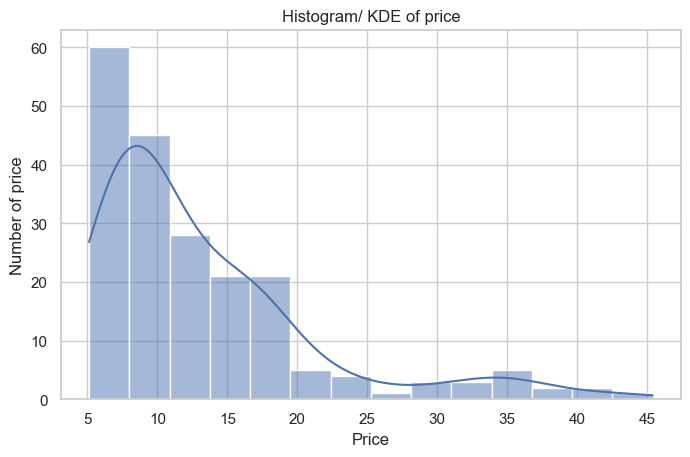

In [139]:
# TODO M2.1: histogram/KDE của price
new_df = df.copy()
new_df["price"] = df["price"]/1000

plt.figure()
sns.histplot(new_df["price"], kde=True)
plt.title('Histogram/ KDE of price')
plt.xlabel("Price")
plt.ylabel('Number of price')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Vì Price nhận giá trị lớn nên em chia 1000 để dễ dàng giảm min, max cũng như visualize dễ dàng hơn
Phân phối price bị lệnh trái, có tần suất lớn nhất nằm trong khoảng từ 5 - 10.

## M2.2 Dataset có cân bằng theo body style không?

number of convertible:  6
number of hardtop:  8
number of hatchback:  70
number of sedan:  96
number of wagon:  25


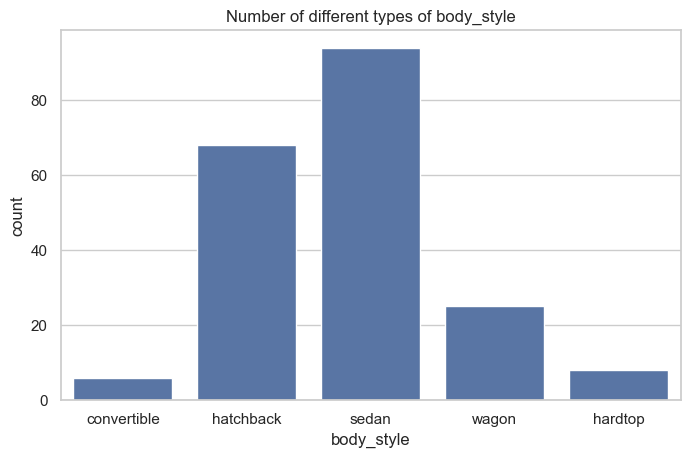

In [143]:
# TODO M2.2: countplot của body_style
data_2 = raw_df.groupby("body_style")
for u,v in data_2:
    print(f'number of {u}: ', len(v))

plt.figure()
sns.countplot(df, x = "body_style")
plt.title("Number of different types of body_style")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Dataset không cân bằng theo body style

## M2.3 Price khác nhau theo body style ra sao?

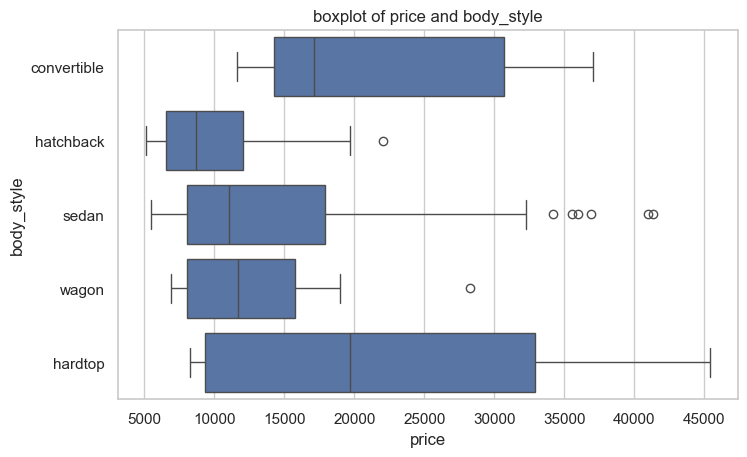

In [144]:
# TODO M2.3: boxplot price theo body_style
plt.figure()
sns.boxplot(df, x = "price", y = "body_style")
plt.title("boxplot of price and body_style")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Nhìn vào đồ thị, ta thấy hardtop chiếm khoảng rộng nhất về price còn batchback lại chiếm khoảng nhỏ nhất về price. body_style sedan là có outliner nhiều nhất.

## M2.4 Engine size liên quan thế nào tới price?

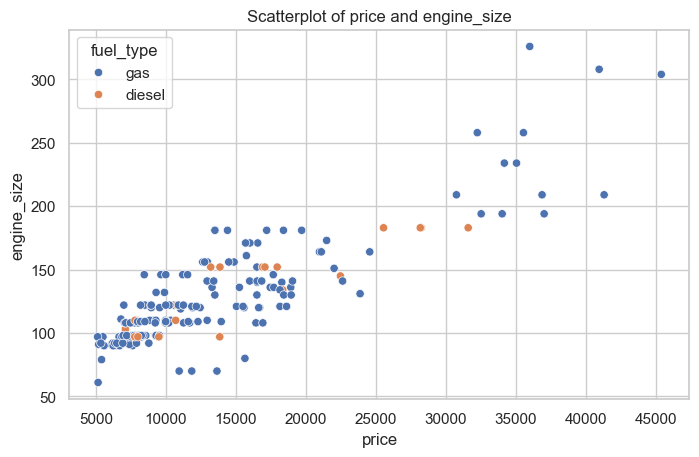

In [145]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type

plt.figure()
sns.scatterplot(df, x = "price", y = "engine_size", hue = "fuel_type")
plt.title("Scatterplot of price and engine_size")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Ta thấy một pattern ở đây là engine_size tăng thì price cũng tăng theo nên engine_size và price có độ tương quan cao

## M2.5 Các feature numeric tương quan ra sao?

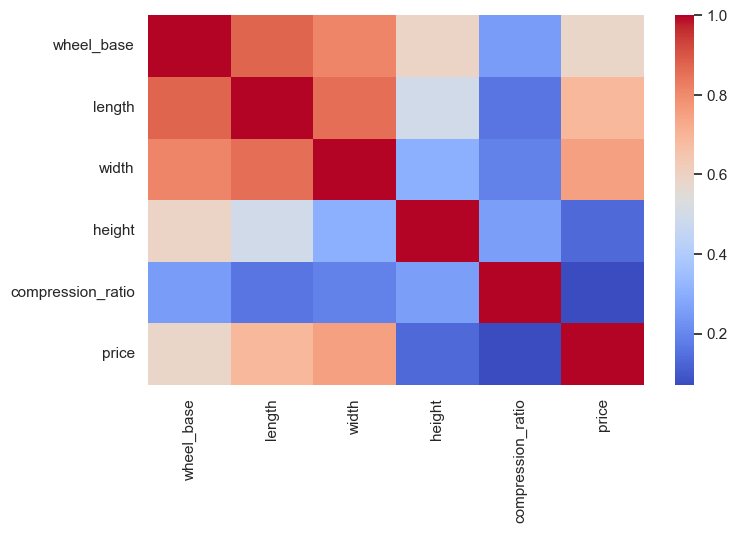

In [151]:
# TODO M2.5: correlation heatmap
corr_matrix = df.select_dtypes(include=['float64']).corr()

plt.figure()
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()


**Nhận xét:** <!-- 1--2 câu -->
Màu càng đỏ thì tương quan càng cao, ở đây ta có thể thấy wheel_base và length hay width có độ tương quan cao. Ngược lại, màu càng xanh dương thì độ tương quan càng thấp, ở đây ta có thể thấy price với compression_ratio hay height có độ tương quan thấp.


## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

<Figure size 800x480 with 0 Axes>

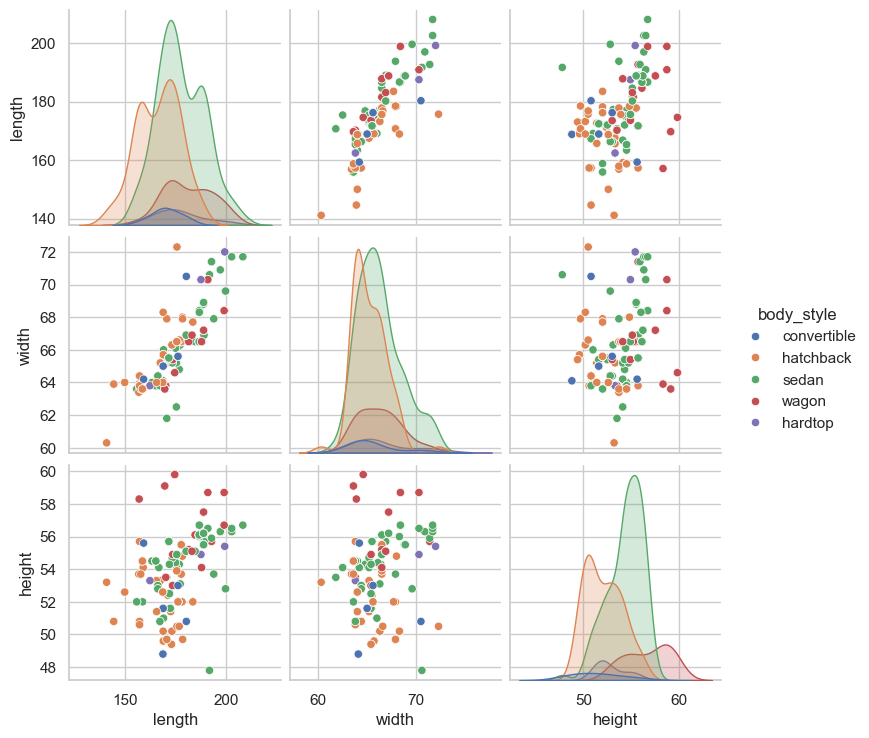

In [158]:
# TODO M2.6: biểu đồ tự chọn
# Câu hỏi: Các loại body_style có feature length, width, height phân bố như thế nào trong không gian 2D ? 
# chart: pairplot

plt.figure()
sns.pairplot(raw_df[["body_style",'length', 'width', "height"]], hue = "body_style")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Nhìn vào đồ thị pairplot, ta thấy khó có thể xây dựng model nếu chỉ sử dụng 3 feature này. Ta nhận thấy rằng width của hatchback và sedan có phân phối gần giống nhau, cũng như phân phối width của hardtop và convertible.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
* 3--5 phát hiện chính có dẫn chứng: 
- Giá xe (Price) tỷ lệ thuận rất mạnh với Kích thước động cơ (Engine Size). engine_price_corr:  0.8738869517981515
- Mất cân bằng dữ liệu ở body_style. Vì: 
    number of convertible:  6
    number of hardtop:  8
    number of hatchback:  70
    number of sedan:  96
    number of wagon:  25
- Giá xe có một phổ rộng (từ 5000 - 45000)
- Giá xe bị lệch trái (theo đồ thị histogram)


* Dataset bị hạn chế:
    + missing value là "?" thay vì np.nan. Cần phải preprocessing trước khi train
    + Dataset từ năm 1985, hiện nay là 2026 nên nếu train mô hình trên data này có thể sẽ không tốt nếu dùng để suy luận cho các hãng xe mới.
    + normalized_losses có 41 missing values.

* Một ví dụ về correlation không đồng nghĩa causation:
- highway_mpg có tương quan nghịch biến rất mạnh với price. Nó ngược với causation là giá càng đắt thì highway_mpg (mức tiết kiệm nhiên liệu) phải giảm chứ ?
- Phân tích: vì price có tương quan với curb_weight và horsepower. Điều này tức là trọng lượng xe tăng, mã lực tăng nên hao nhiên liệu.

* một câu hỏi nên phân tích tiếp:
- Dựa vào dataset như thế này, cần phải loại bỏ feature nào ? Giữ feature nào ? Dựa vào đâu để biết nên loại hay giữ ?


In [169]:
print("Tương quan của price và highway_mpg:\n ", X_auto[["price", "highway_mpg"]].corr())
print("Tương quan của price và curb_weight:\n ", X_auto[["price", "curb_weight"]].corr())
print("Tương quan của price và horsepower:\n ", X_auto[["price", "horsepower"]].corr())


Tương quan của price và highway_mpg:
                 price  highway_mpg
price        1.00000     -0.70523
highway_mpg -0.70523      1.00000
Tương quan của price và curb_weight:
                 price  curb_weight
price        1.00000      0.83509
curb_weight  0.83509      1.00000
Tương quan của price và horsepower:
                 price  horsepower
price       1.000000    0.810533
horsepower  0.810533    1.000000
